In [1]:
import os

output_dir = 'images'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)
    print(f"Created directory: {output_dir}")
else:
    print(f"Directory already exists: {output_dir}")

Directory already exists: images


In [2]:
!pip install --no-cache-dir scikit-learn==1.9.0 scikeras==0.13.0

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam, SGD, RMSprop
from tensorflow.keras.utils import to_categorical

from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.metrics import f1_score, confusion_matrix, classification_report
from sklearn.model_selection import RandomizedSearchCV

import warnings
warnings.filterwarnings("ignore")

In [4]:
import sklearn
import scikeras
import keras
import tensorflow as tf

print("sklearn:", sklearn.__version__)
print("scikeras:", scikeras.__version__)
print("keras:", keras.__version__)
print("tensorflow:", tf.__version__)

from scikeras.wrappers import KerasClassifier

print("SciKeras import OK")

sklearn: 1.9.0
scikeras: 0.13.0
keras: 3.13.2
tensorflow: 2.20.0
SciKeras import OK


In [5]:
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

print("Training Images:", x_train.shape)
print("Training Labels:", y_train.shape)
print("Testing Images:", x_test.shape)
print("Testing Labels:", y_test.shape)

Training Images: (60000, 28, 28)
Training Labels: (60000,)
Testing Images: (10000, 28, 28)
Testing Labels: (10000,)


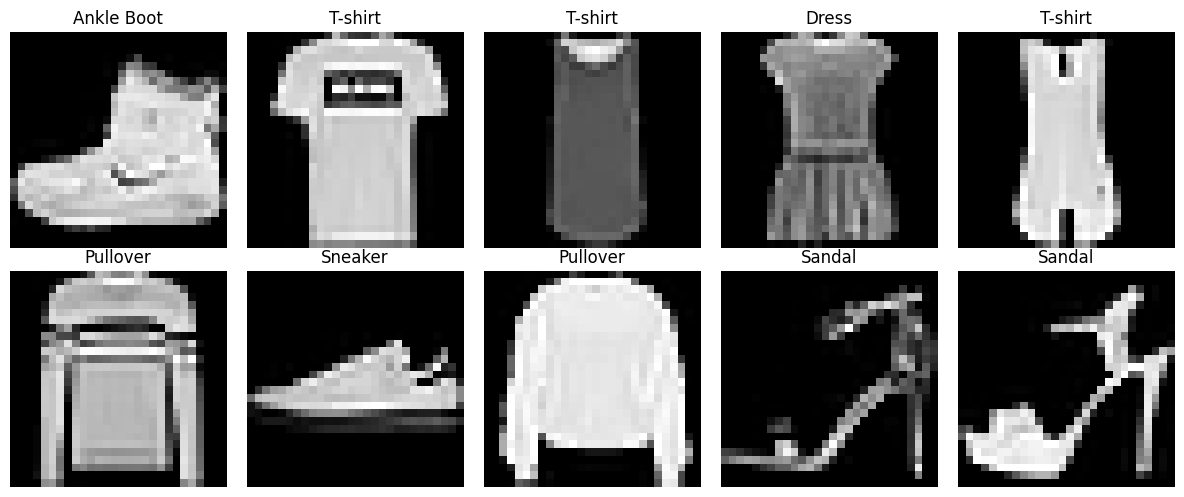

In [6]:
# displaying sample images
class_names = [
    "T-shirt",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle Boot"
]

fig_sample_images = plt.figure(figsize=(12,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i], cmap="gray")
    plt.title(class_names[y_train[i]])
    plt.axis("off")

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'sample_images.png'), dpi=600)
plt.show()
plt.close(fig_sample_images)

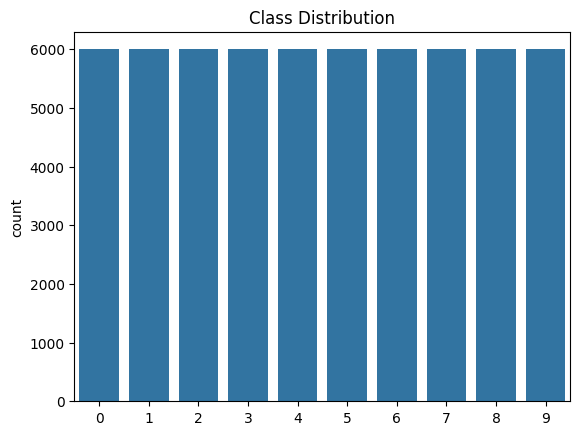

In [7]:
# plotting class distribution
fig_class_distribution = plt.figure()
sns.countplot(x=y_train)
plt.title("Class Distribution")
plt.savefig(os.path.join(output_dir, 'class_distribution.png'), dpi=600)
plt.show()
plt.close(fig_class_distribution)

In [8]:
# preprocessing

print("Before Flattening:", x_train.shape, x_test.shape)

x_train = x_train.reshape(-1,784).astype("float32")/255.0
x_test = x_test.reshape(-1,784).astype("float32")/255.0

print("After Flattening:", x_train.shape, x_test.shape)

y_train_cat = to_categorical(y_train,10)
y_test_cat = to_categorical(y_test,10)

Before Flattening: (60000, 28, 28) (10000, 28, 28)
After Flattening: (60000, 784) (10000, 784)


In [9]:
# baseline model
baseline = Sequential([
    Input(shape=(784,)),
    Dense(128,activation="relu"),
    Dense(64,activation="relu"),
    Dense(10,activation="softmax")
])

baseline.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

baseline.summary()

I0000 00:00:1784950726.690101    1397 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1784950726.692352    1397 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
# model training
history = baseline.fit(
    x_train,
    y_train_cat,
    validation_split=0.2,
    epochs=20,
    batch_size=32,
    verbose=1
)

Epoch 1/20
  71/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.5166 - loss: 1.4386

I0000 00:00:1784950735.476691    1469 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8175 - loss: 0.5117 - val_accuracy: 0.8508 - val_loss: 0.4155
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8626 - loss: 0.3767 - val_accuracy: 0.8707 - val_loss: 0.3584
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8746 - loss: 0.3366 - val_accuracy: 0.8776 - val_loss: 0.3416
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8841 - loss: 0.3151 - val_accuracy: 0.8767 - val_loss: 0.3439
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8895 - loss: 0.2971 - val_accuracy: 0.8809 - val_loss: 0.3282
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8968 - loss: 0.2797 - val_accuracy: 0.8767 - val_loss: 0.3343
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8995 - loss: 0.2704 - val_accuracy: 0.8838 - val_loss: 0.3301
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9032 - loss: 0.2578 - val_accurac

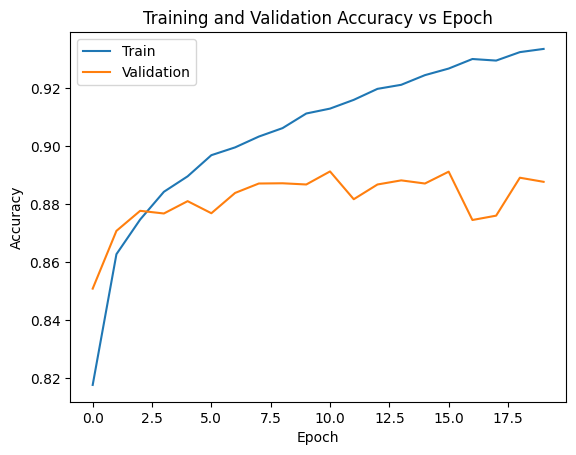

In [11]:
fig_accuracy = plt.figure()
plt.plot(history.history["accuracy"],label="Train")
plt.plot(history.history["val_accuracy"],label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Training and Validation Accuracy vs Epoch")
plt.savefig(os.path.join(output_dir, 'training_validation_accuracy.png'), dpi=600)
plt.show()
plt.close(fig_accuracy)

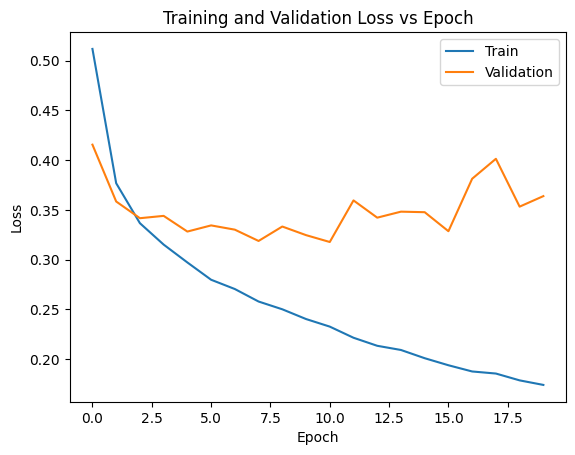

In [12]:
fig_loss = plt.figure()
plt.plot(history.history["loss"],label="Train")
plt.plot(history.history["val_loss"],label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Training and Validation Loss vs Epoch")
plt.savefig(os.path.join(output_dir, 'training_validation_loss.png'), dpi=600)
plt.show()
plt.close(fig_loss)

In [13]:
# evaluation
pred = baseline.predict(x_test)
pred_classes = np.argmax(pred,axis=1)

acc = accuracy_score(y_test,pred_classes)
pre = precision_score(y_test,pred_classes,average="weighted")
rec = recall_score(y_test,pred_classes,average="weighted")
f1 = f1_score(y_test,pred_classes,average="weighted")

print("Accuracy :",acc)
print("Precision:",pre)
print("Recall   :",rec)
print("F1 Score :",f1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Accuracy : 0.882
Precision: 0.8837972296557256
Recall   : 0.882
F1 Score : 0.8825092079097246


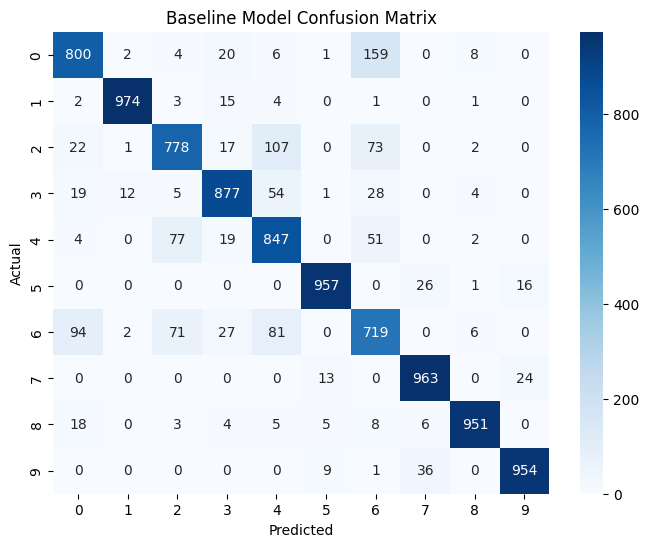

In [14]:
cm = confusion_matrix(y_test,pred_classes)

fig_baseline_cm = plt.figure(figsize=(8,6))
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Baseline Model Confusion Matrix")
plt.savefig(os.path.join(output_dir, 'baseline_confusion_matrix.png'), dpi=600)
plt.show()
plt.close(fig_baseline_cm)

In [15]:
print(classification_report(y_test,pred_classes,target_names=class_names))

              precision    recall  f1-score   support

     T-shirt       0.83      0.80      0.82      1000
     Trouser       0.98      0.97      0.98      1000
    Pullover       0.83      0.78      0.80      1000
       Dress       0.90      0.88      0.89      1000
        Coat       0.77      0.85      0.81      1000
      Sandal       0.97      0.96      0.96      1000
       Shirt       0.69      0.72      0.70      1000
     Sneaker       0.93      0.96      0.95      1000
         Bag       0.98      0.95      0.96      1000
  Ankle Boot       0.96      0.95      0.96      1000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



In [ ]:
# Hyperparameter Optimization

In [16]:
def create_model(hidden_layers=2,
                 neurons=128,
                 learning_rate=0.001,
                 optimizer="adam",
                 activation="relu",
                 dropout=0.0):

    model = Sequential()
    model.add(Input(shape=(784,)))

    for i in range(hidden_layers):
        model.add(Dense(neurons,activation=activation))
        if dropout>0:
            model.add(Dropout(dropout))

    model.add(Dense(10,activation="softmax"))

    if optimizer=="adam":
        opt = Adam(learning_rate=learning_rate)
    elif optimizer=="sgd":
        opt = SGD(learning_rate=learning_rate)
    else:
        opt = RMSprop(learning_rate=learning_rate)

    model.compile(
        optimizer=opt,
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [21]:
from scikeras.wrappers import KerasClassifier

model = KerasClassifier(
    model=create_model,
    verbose=0,
    random_state=42
)

params = {
    "model__hidden_layers":[1,2,3],
    "model__neurons":[32,64,128,256],
    "model__learning_rate":[0.1,0.01,0.001],
    "model__optimizer":["adam","sgd","rmsprop"],
    "model__activation":["relu","tanh","sigmoid"],
    "model__dropout":[0.0,0.2,0.5],
    "batch_size":[16,32,64,128],
    "epochs":[10,20,30]
}

search = RandomizedSearchCV(
    estimator=model,
    param_distributions=params,
    n_iter=3,
    cv=5,
    scoring="accuracy",
    random_state=42,
    n_jobs=1
)

search.fit(x_train,y_train_cat)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KerasClassifi..._weight=None )
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'batch_size': [16, 32, ...], 'epochs': [10, 20, ...], 'model__activation': ['relu', 'tanh', ...], 'model__dropout': [0.0, 0.2, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",3
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.A

In [22]:
print("Best Parameters:")
print(search.best_params_)

print("\nBest CV Accuracy:")
print(search.best_score_)

Best Parameters:
{'model__optimizer': 'rmsprop', 'model__neurons': 128, 'model__learning_rate': 0.001, 'model__hidden_layers': 3, 'model__dropout': 0.2, 'model__activation': 'sigmoid', 'epochs': 10, 'batch_size': 16}

Best CV Accuracy:
0.8768499999999999


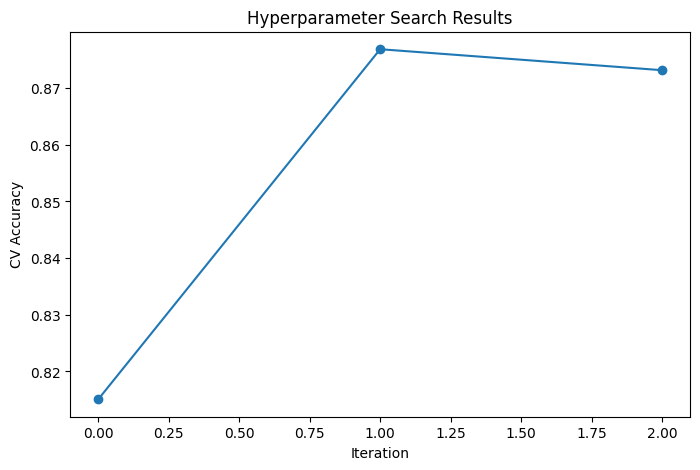

In [23]:
results = pd.DataFrame(search.cv_results_)

fig_hyperparameter_results = plt.figure(figsize=(8,5))
plt.plot(results["mean_test_score"],marker="o")
plt.xlabel("Iteration")
plt.ylabel("CV Accuracy")
plt.title("Hyperparameter Search Results")
plt.savefig(os.path.join(output_dir, 'hyperparameter_search_results.png'), dpi=600)
plt.show()
plt.close(fig_hyperparameter_results)

In [26]:
# optimized model
best = search.best_estimator_

pred_best = best.predict(x_test)

# convert one-hot encoded predictions back to class indices
if pred_best.ndim > 1:
    pred_best = np.argmax(pred_best, axis=1)

acc2 = accuracy_score(y_test,pred_best)
pre2 = precision_score(y_test,pred_best,average="weighted")
rec2 = recall_score(y_test,pred_best,average="weighted")
f12 = f1_score(y_test,pred_best,average="weighted")

print("Accuracy :",acc2)
print("Precision:",pre2)
print("Recall   :",rec2)
print("F1 Score :",f12)


Accuracy : 0.8596
Precision: 0.8688607536161511
Recall   : 0.8596
F1 Score : 0.8562774131667106


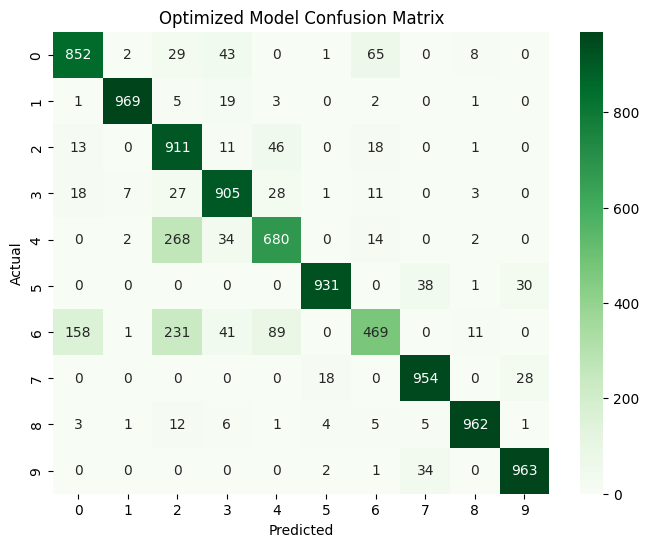

In [27]:
cm = confusion_matrix(y_test,pred_best)

fig_optimized_cm = plt.figure(figsize=(8,6))
sns.heatmap(cm,annot=True,fmt="d",cmap="Greens")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Optimized Model Confusion Matrix")
plt.savefig(os.path.join(output_dir, 'optimized_confusion_matrix.png'), dpi=600)
plt.show()
plt.close(fig_optimized_cm)

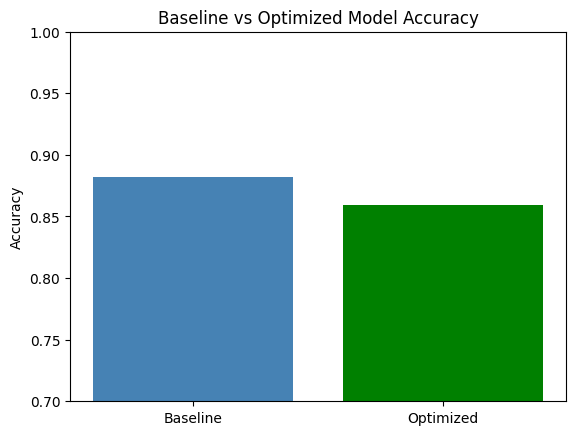

In [28]:
models = ["Baseline","Optimized"]
scores = [acc,acc2]

fig_accuracy_comparison = plt.figure()
plt.bar(models,scores,color=["steelblue","green"])
plt.ylabel("Accuracy")
plt.ylim(0.7,1.0)
plt.title("Baseline vs Optimized Model Accuracy")
plt.savefig(os.path.join(output_dir, 'accuracy_comparison.png'), dpi=600)
plt.show()
plt.close(fig_accuracy_comparison)

In [29]:
comparison = pd.DataFrame({
    "Metric":["Accuracy","Precision","Recall","F1 Score"],
    "Baseline":[acc,pre,rec,f1],
    "Optimized":[acc2,pre2,rec2,f12]
})

comparison

,Metric,Baseline,Optimized
0,Accuracy,0.882000,0.859600
1,Precision,0.883797,0.868861
2,Recall,0.882000,0.859600
3,F1 Score,0.882509,0.856277
